In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix 
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.metrics import r2_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
train = pd.read_csv("yelp_train.csv")
test = pd.read_csv("yelp_test.csv")

train["fourOrAbove"] = (train["stars"] >= 4).astype(int)
test["fourOrAbove"] = (test["stars"] >= 4).astype(int)

X_train = train.drop(columns=["stars", "fourOrAbove"])
y_train = train["fourOrAbove"]

X_test = test.drop(columns=["stars", "fourOrAbove"])
y_test = test["fourOrAbove"]

X_train = X_train.fillna("(Missing)")
X_test = X_test.fillna("(Missing)")

cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def get_metrics(model, X_test, y_test):
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)
    return acc, tpr, fpr

In [3]:
# A) Logistic regression baseline 
log_preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols)
])

log_model = Pipeline([
    ("prep", log_preprocess),
    ("logreg", LogisticRegression(max_iter=5000))
])

log_model.fit(X_train, y_train)
log_acc, log_tpr, log_fpr = get_metrics(log_model, X_test, y_test)

print("Logistic Regression Test Accuracy:", log_acc)

Logistic Regression Test Accuracy: 0.6670386904761905


Best ccp_alpha: 0.0005
CART Test Accuracy: 0.6506696428571429


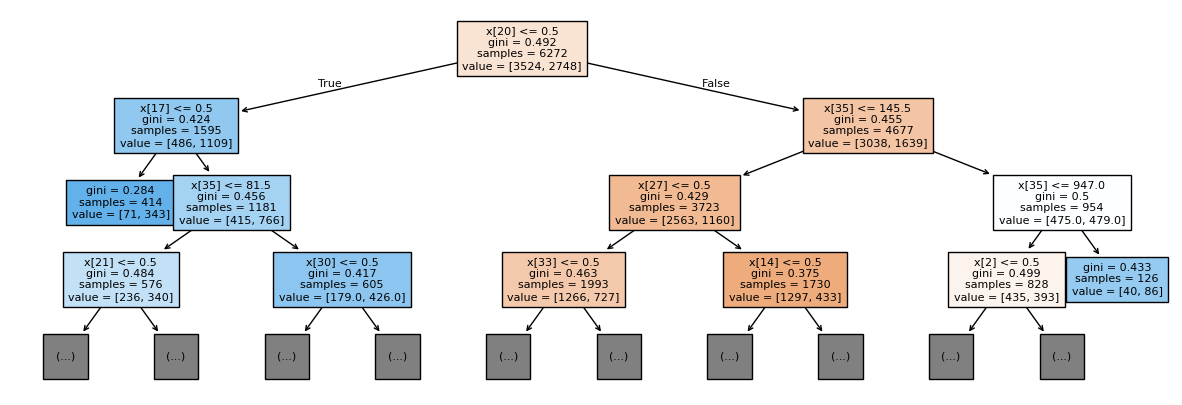

In [4]:
# B) CART with Cross validation
tree_preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols)
])
base_tree = Pipeline([
    ("prep", tree_preprocess),
    ("tree", DecisionTreeClassifier(random_state=42))
])
ccp_values = [0, 0.0001, 0.0005, 0.001, 0.005, 0.01]
tree_grid = GridSearchCV(
    base_tree,
    param_grid={"tree__ccp_alpha": ccp_values},
    cv=cv,
    scoring="accuracy"
)
tree_grid.fit(X_train, y_train)
tree_model = tree_grid.best_estimator_
tree_acc, tree_tpr, tree_fpr = get_metrics(tree_model, X_test, y_test)
print("Best ccp_alpha:", tree_grid.best_params_["tree__ccp_alpha"])
print("CART Test Accuracy:", tree_acc)
plt.figure(figsize=(15, 5))
plot_tree(
    tree_model.named_steps["tree"],
    max_depth=3,
    filled=True,
    fontsize=8
)
plt.show()

In [5]:
# C) Random Forest with Cross - Validation 
rf_model = Pipeline([
    ("prep", tree_preprocess),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ))
])

rf_grid = GridSearchCV(
    rf_model,
    param_grid={"rf__max_features": ["sqrt", "log2", 0.3, 0.5]},
    cv=cv,
    scoring="accuracy"
)

rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
rf_acc, rf_tpr, rf_fpr = get_metrics(best_rf, X_test, y_test)

print("Best max_features:", rf_grid.best_params_["rf__max_features"])
print("Random Forest Test Accuracy:", rf_acc)


Best max_features: 0.5
Random Forest Test Accuracy: 0.6577380952380952


In [6]:
# D) Cat Boost 
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)
cat_feature_indices = [X_train.columns.get_loc(col) for col in cat_cols]
cat_grid = [
    {"iterations": 300, "learning_rate": 0.05, "depth": 4},
    {"iterations": 500, "learning_rate": 0.03, "depth": 4},
    {"iterations": 300, "learning_rate": 0.05, "depth": 6}
]
best_score = 0
best_params = None
best_catboost = None

for params in cat_grid:
    model = CatBoostClassifier(
        **params,
        loss_function="Logloss",
        verbose=0,
        random_seed=42
    )

    model.fit(X_tr, y_tr, cat_features=cat_feature_indices)
    val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)

    print(params, "Validation accuracy:", val_acc)

    if val_acc > best_score:
        best_score = val_acc
        best_params = params
        best_catboost = model

best_catboost.fit(X_train, y_train, cat_features=cat_feature_indices)
cat_acc, cat_tpr, cat_fpr = get_metrics(best_catboost, X_test, y_test)
print("Best CatBoost params:", best_params)
print("CatBoost validation accuracy:", best_score)
print("CatBoost test accuracy:", cat_acc)

{'iterations': 300, 'learning_rate': 0.05, 'depth': 4} Validation accuracy: 0.6804780876494024
{'iterations': 500, 'learning_rate': 0.03, 'depth': 4} Validation accuracy: 0.6764940239043825
{'iterations': 300, 'learning_rate': 0.05, 'depth': 6} Validation accuracy: 0.6876494023904383
Best CatBoost params: {'iterations': 300, 'learning_rate': 0.05, 'depth': 6}
CatBoost validation accuracy: 0.6876494023904383
CatBoost test accuracy: 0.6804315476190477


In [7]:
#E
majority_class = y_train.mode()[0]
majority_preds = np.repeat(majority_class, len(y_test))
tn, fp, fn, tp = confusion_matrix(y_test, majority_preds).ravel()
majority_acc = accuracy_score(y_test, majority_preds)
majority_tpr = tp / (tp + fn)
majority_fpr = fp / (fp + tn)

results = pd.DataFrame({
    "Model": [
        "Majority Class Baseline",
        "Logistic Regression",
        "CART",
        "Random Forest",
        "CatBoost"
    ],
    "Accuracy": [
        majority_acc,
        log_acc,
        tree_acc,
        rf_acc,
        cat_acc
    ],
    "TPR": [
        majority_tpr,
        log_tpr,
        tree_tpr,
        rf_tpr,
        cat_tpr
    ],
    "FPR": [
        majority_fpr,
        log_fpr,
        tree_fpr,
        rf_fpr,
        cat_fpr
    ]
})

results

,Model,Accuracy,TPR,FPR
0,Majority Class Baseline,0.551339,0.000000,0.000000
1,Logistic Regression,0.667039,0.484245,0.184211
2,CART,0.650670,0.508292,0.233468
3,Random Forest,0.657738,0.579602,0.278677
4,CatBoost,0.680432,0.491708,0.165992


In [8]:
# F) tips 
summary = train.groupby("fourOrAbove").mean(numeric_only=True).T
summary["difference_high_minus_low"] = summary[1] - summary[0]
summary.sort_values("difference_high_minus_low", ascending=False).head(10)

fourOrAbove,0,1,difference_high_minus_low
review_count,119.804484,248.819505,129.015022
stars,2.907917,4.266739,1.358822
